In [2]:
import pandas as pd

In [4]:
df = pd.read_csv("shipments.csv")

In [6]:
display(df.head())

,shipment_id,timestamp,severity,thread,source,event,station,box_barcode,articles,exp_weight_kg,...,abs_weight_diff,print_quality_pct,line_speed_mps,slam,iso_grade,pckg_problem_found,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot
0,Sp260318090056,2026-01-12 00:02:14,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-04,BC_MEDIUM200,5.0,1.791,...,0.06519,NaN,NaN,NaN,NaN,N,0.06519,0.036,0.043698,1
1,Sp260318090057,2026-01-12 00:02:28,INFO,LabelThread-3,com.logistic.labelmachine.SystemManager,Label printed,Station-06,XX_LARGE60,18.0,4.247,...,0.02591,100.00000,2.21,SLAM5_LP1,A,NaN,-0.02591,0.006,-0.025054,0
2,Sp260318090058,2026-01-12 00:02:42,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-07,BC_LARGE400,3.0,3.715,...,0.19690,NaN,NaN,NaN,NaN,N,0.19690,0.053,0.152320,1
3,Sp260318090059,2026-01-12 00:02:55,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-05,XX_LARGE80,20.0,3.986,...,0.17778,NaN,NaN,NaN,NaN,Y,-0.17778,0.045,0.129948,1
4,Sp260318090060,2026-01-12 00:03:09,INFO,LabelThread-4,com.logistic.labelmachine.SystemManager,Label printed,Station-02,BC_LARGE400,8.0,5.585,...,0.05082,99.96875,1.87,SLAM5_LP2,A,NaN,-0.05082,0.009,-0.016200,0


In [8]:
df.shape

(5900, 23)

In [10]:
df.columns

Index(['shipment_id', 'timestamp', 'severity', 'thread', 'source', 'event',
       'station', 'box_barcode', 'articles', 'exp_weight_kg', 'act_weight_kg',
       'tare_weight_kg', 'product_weight_kg', 'abs_weight_diff',
       'print_quality_pct', 'line_speed_mps', 'slam', 'iso_grade',
       'pckg_problem_found', 'weight_diff', 'weight_diff_ratio',
       'distance_to_threshold', 'is_kot'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5900 entries, 0 to 5899
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   shipment_id            5900 non-null   object 
 1   timestamp              5900 non-null   object 
 2   severity               5900 non-null   object 
 3   thread                 5900 non-null   object 
 4   source                 5900 non-null   object 
 5   event                  5900 non-null   object 
 6   station                5760 non-null   object 
 7   box_barcode            5900 non-null   object 
 8   articles               5760 non-null   float64
 9   exp_weight_kg          5760 non-null   float64
 10  act_weight_kg          5760 non-null   float64
 11  tare_weight_kg         5760 non-null   float64
 12  product_weight_kg      5760 non-null   float64
 13  abs_weight_diff        5760 non-null   float64
 14  print_quality_pct      4456 non-null   float64
 15  line

In [14]:
df.isnull().sum()

shipment_id                 0
timestamp                   0
severity                    0
thread                      0
source                      0
event                       0
station                   140
box_barcode                 0
articles                  140
exp_weight_kg             140
act_weight_kg             140
tare_weight_kg            140
product_weight_kg         140
abs_weight_diff           140
print_quality_pct        1444
line_speed_mps           1444
slam                     1444
iso_grade                1444
pckg_problem_found       4596
weight_diff               140
weight_diff_ratio         140
distance_to_threshold     140
is_kot                      0
dtype: int64

In [8]:
df.describe()

,articles,exp_weight_kg,act_weight_kg,tare_weight_kg,product_weight_kg,abs_weight_diff,print_quality_pct,line_speed_mps,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot
count,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000,4456.000000,4456.000000,5760.000000,5760.000000,5760.000000,5900.000000
mean,10.649826,3.173276,3.316063,0.143410,3.172653,0.046323,94.066534,1.592338,0.000623,0.014476,0.008244,0.221017
std,5.744195,1.622587,1.622862,0.074865,1.623382,0.059203,3.493632,0.460045,0.075172,0.015028,0.054266,0.414967
min,1.000000,0.380000,0.450170,0.070000,0.376240,0.001370,88.012500,0.800000,-0.358010,0.003000,-0.052844,0.000000
25%,6.000000,1.788750,1.950610,0.090000,1.779930,0.013895,91.043750,1.210000,-0.026343,0.006000,-0.017162,0.000000
50%,11.000000,3.121000,3.270990,0.120000,3.127385,0.026160,94.081250,1.570000,-0.002295,0.009000,-0.007018,0.000000
75%,16.000000,4.590250,4.730252,0.240000,4.588150,0.048165,97.112500,1.980000,0.025960,0.012000,-0.000645,0.000000
max,20.000000,5.999000,6.485060,0.290000,6.305010,0.388360,100.000000,2.400000,0.388360,0.065000,0.316552,1.000000


In [16]:
# Kickout-Pakete vs normale Pakete
print(df["is_kot"].value_counts())

is_kot
0    4596
1    1304
Name: count, dtype: int64


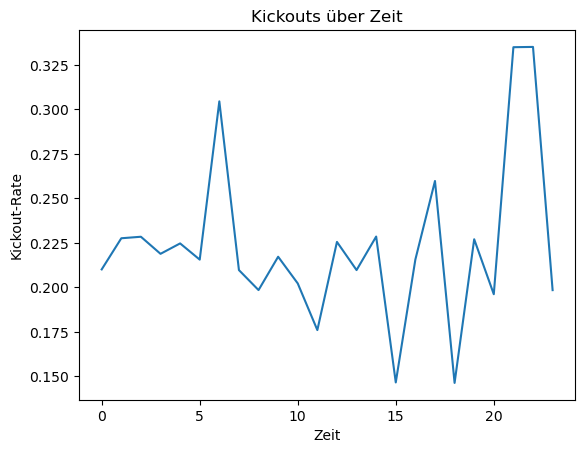

In [18]:
import matplotlib.pyplot as plt
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour
kickout_rate = df.groupby("hour")["is_kot"].mean()
plt.figure()
plt.plot(kickout_rate.index, kickout_rate.values)

plt.xlabel("Zeit")
plt.ylabel("Kickout-Rate")
plt.title("Kickouts über Zeit")

plt.show()

In [11]:
# Unterscheiden sich Gewichtsabweichungen zwischen Kickout-Paketen und normalen Pakete?
df.groupby("is_kot")["abs_weight_diff"].mean()

is_kot
0    0.023725
1    0.123542
Name: abs_weight_diff, dtype: float64

In [12]:
# Kickout-Rate abhängig von der Sation?
df.groupby(["station"])["is_kot"].mean()

station
Station-01    0.187243
Station-02    0.224839
Station-03    0.234951
Station-04    0.216920
Station-05    0.230608
Station-06    0.238776
Station-07    0.194389
Station-08    0.198330
Station-09    0.186813
Station-10    0.209607
Station-11    0.323529
Station-12    0.267606
Name: is_kot, dtype: float64

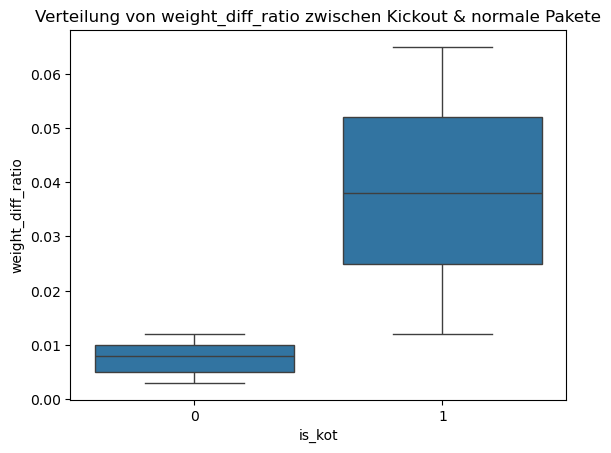

In [13]:
# Unterscheidet sich die Verteilung von weight_diff, weight_diff_ratio oder act_weight_kg zwischen Kickout und normalen Paketen?
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="is_kot", y="weight_diff_ratio", data=df)

plt.title("Verteilung von weight_diff_ratio zwischen Kickout & normale Pakete")
plt.show()

In [14]:
# Gibt es Auffälligkeiten innerhalb der Schichtwechselzeiten (06:00, 14:00, 22:00)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["hour"] = df["timestamp"].dt.hour

# Kickout-Rate pro Stunde
df.groupby("hour")["is_kot"].mean().sort_index()

hour
0     0.210117
1     0.227612
2     0.228464
3     0.218868
4     0.224719
5     0.215613
6     0.304527
7     0.209738
8     0.198502
9     0.217228
10    0.202247
11    0.176030
12    0.225564
13    0.209738
14    0.228571
15    0.146617
16    0.215686
17    0.259804
18    0.146341
19    0.227053
20    0.196172
21    0.334951
22    0.335106
23    0.198473
Name: is_kot, dtype: float64

<Axes: xlabel='hour'>

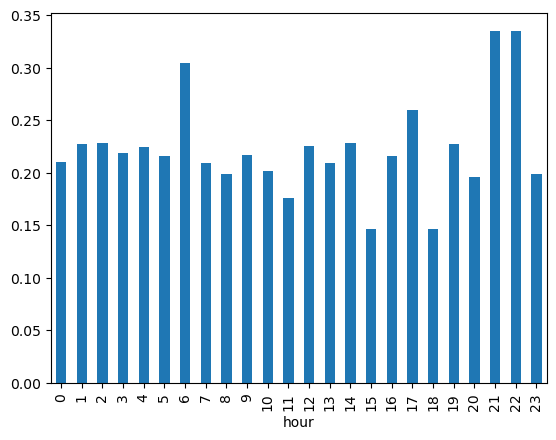

In [15]:
df.groupby("hour")["is_kot"].mean().plot(kind="bar")

In [16]:
#Der höchste Wert tritt um 06:00 Uhr auf. In dieser Stunde beträgt die Kickout-Rate ungefähr 29 %, was deutlich über dem durchschnittlichen Wert von etwa 20 % liegt. 
#Dieser Peak fällt zeitlich mit dem Beginn der Frühschicht zusammen. Eine mögliche Erklärung hierfür sind Prozesse rund um den Schichtwechsel, 
#wie beispielsweise Maschinenstart, Kalibrierung der Sensorik oder eine Umstellung der Bedienung durch neue Operatoren.
#Ein weiterer erhöhter Wert zeigt sich um 12:00 Uhr, wo die Kickout-Rate etwa 25 % beträgt. Dies könnte auf ein erhöhtes Paketvolumen während der Mittagszeit zurückzuführen sein,
#wodurch die Anlage unter höherer Last arbeitet und Fehler wahrscheinlicher werden.

In [17]:
df.groupby("slam")["is_kot"].mean().sort_index()

slam
SLAM5_LP1    0.0
SLAM5_LP2    0.0
Name: is_kot, dtype: float64

In [18]:
# Stunden 5 bis 7 filtern
df_shift = df[df["hour"].between(5,7)]

# Kickout-Rate pro Stunde in diesem Bereich
df_shift.groupby("hour")["is_kot"].mean()

hour
5    0.215613
6    0.304527
7    0.209738
Name: is_kot, dtype: float64

In [19]:
df_shift.groupby("hour")["is_kot"].agg(["count","mean"])

,count,mean
hour,,
5,269,0.215613
6,243,0.304527
7,267,0.209738


In [20]:
# nur normale Pakete
df_normal = df[df["is_kot"] == 0]

# Statistik der ratio
df_normal["weight_diff_ratio"].describe()

count    4456.000000
mean        0.007478
std         0.002614
min         0.003000
25%         0.005000
50%         0.008000
75%         0.010000
max         0.012000
Name: weight_diff_ratio, dtype: float64

In [21]:
df_normal[df_normal["weight_diff_ratio"] > 0.010]["weight_diff_ratio"].count()

702

In [22]:
df_kot = df[df["is_kot"] == 1]
df_kot["weight_diff_ratio"].describe()


count    1304.000000
mean        0.038387
std         0.015333
min         0.012000
25%         0.025000
50%         0.038000
75%         0.052000
max         0.065000
Name: weight_diff_ratio, dtype: float64

In [23]:
df_kot[df_kot["weight_diff_ratio"] < 0.015]["weight_diff_ratio"].count()

70

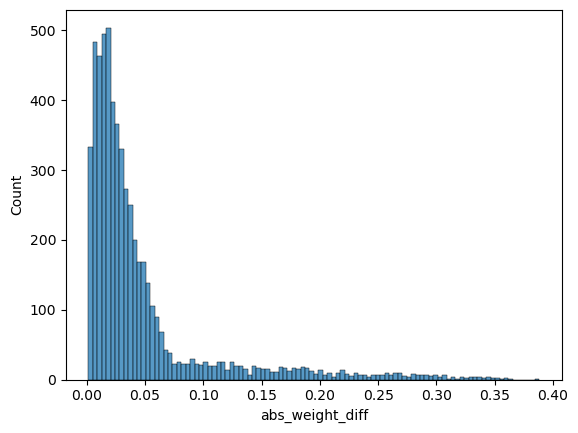

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data=df, x="abs_weight_diff")
plt.show()


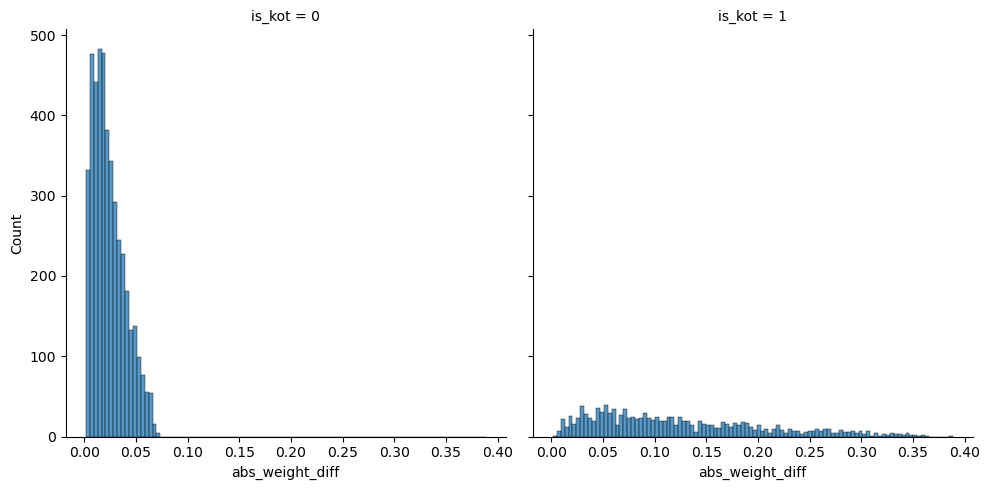

In [25]:
sns.displot(data=df, x="abs_weight_diff", col="is_kot")

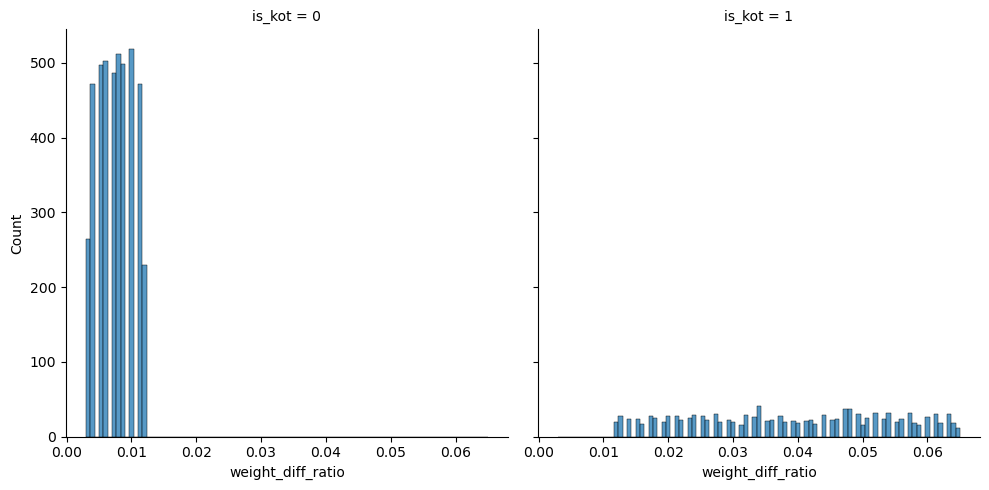

In [26]:
sns.displot(data=df, x="weight_diff_ratio", col="is_kot")

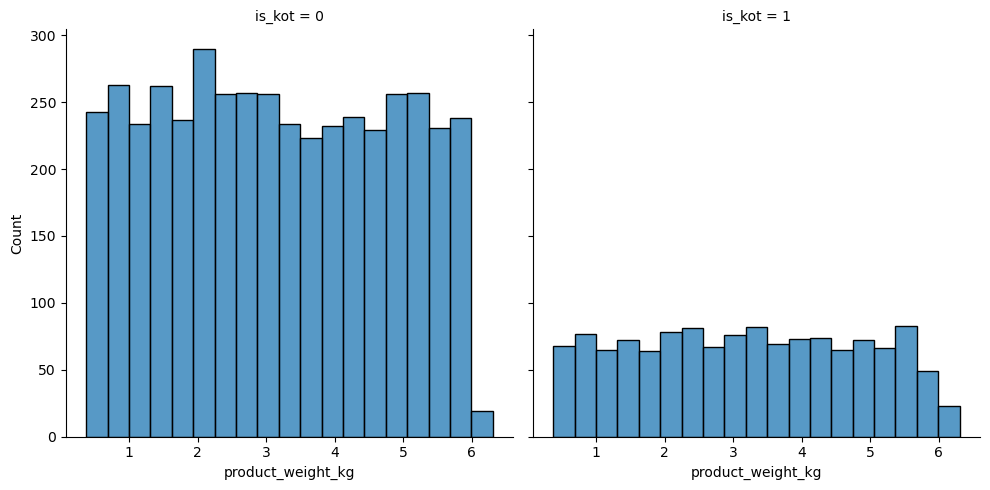

In [27]:
sns.displot(data = df, x = "product_weight_kg", col = "is_kot")

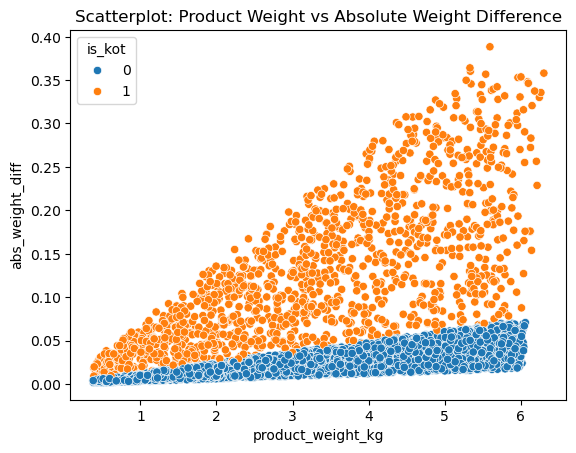

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="product_weight_kg",
    y="abs_weight_diff",
    hue="is_kot"
)

plt.xlabel("product_weight_kg")
plt.ylabel("abs_weight_diff")
plt.title("Scatterplot: Product Weight vs Absolute Weight Difference")

plt.show()

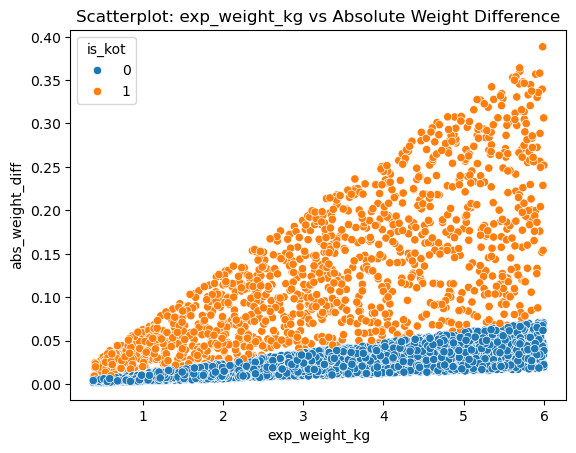

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="exp_weight_kg",
    y="abs_weight_diff",
    hue="is_kot"
)

plt.xlabel("exp_weight_kg")
plt.ylabel("abs_weight_diff")
plt.title("Scatterplot: exp_weight_kg vs Absolute Weight Difference")

plt.show()

In [30]:
df[["product_weight_kg", "exp_weight_kg"]].corr()

,product_weight_kg,exp_weight_kg
product_weight_kg,1.000000,0.998927
exp_weight_kg,0.998927,1.000000


In [31]:
df_kickout = df[df["is_kot"] == 1]

In [32]:
df_kickout

,shipment_id,timestamp,severity,thread,source,event,station,box_barcode,articles,exp_weight_kg,...,print_quality_pct,line_speed_mps,slam,iso_grade,pckg_problem_found,weight_diff,weight_diff_ratio,distance_to_threshold,is_kot,hour
0,Sp260318090056,2026-01-12 00:02:14,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-04,BC_MEDIUM200,5.0,1.791,...,NaN,NaN,NaN,NaN,N,0.06519,0.036,0.043698,1,0
2,Sp260318090058,2026-01-12 00:02:42,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-07,BC_LARGE400,3.0,3.715,...,NaN,NaN,NaN,NaN,N,0.19690,0.053,0.152320,1,0
3,Sp260318090059,2026-01-12 00:02:55,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-05,XX_LARGE80,20.0,3.986,...,NaN,NaN,NaN,NaN,Y,-0.17778,0.045,0.129948,1,0
13,Sp260318090069,2026-01-12 00:05:08,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-07,RK_SMALL90,11.0,4.837,...,NaN,NaN,NaN,NaN,N,-0.10496,0.022,0.046916,1,0
17,Sp260318090073,2026-01-12 00:06:04,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-10,RK_SMALL60,3.0,0.669,...,NaN,NaN,NaN,NaN,N,-0.03653,0.055,0.028502,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5884,Sp260318095940,2026-01-12 23:55:37,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-11,RK_SMALL60,20.0,1.185,...,NaN,NaN,NaN,NaN,N,0.07300,0.062,0.058780,1,23
5886,Sp260318095942,2026-01-12 23:56:04,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-10,RK_SMALL90,17.0,2.927,...,NaN,NaN,NaN,NaN,N,-0.05386,0.018,0.018736,1,23
5887,Sp260318095943,2026-01-12 23:56:19,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-08,XX_LARGE80,18.0,2.437,...,NaN,NaN,NaN,NaN,Y,-0.08408,0.035,0.054836,1,23
5891,Sp260318095947,2026-01-12 23:57:13,WARN,KickoutThread-1,com.logistic.conveyer.ScaleHandlerSys,Overweight detected,Station-08,BC_LARGE400,7.0,2.505,...,NaN,NaN,NaN,NaN,N,0.08768,0.035,0.057620,1,23


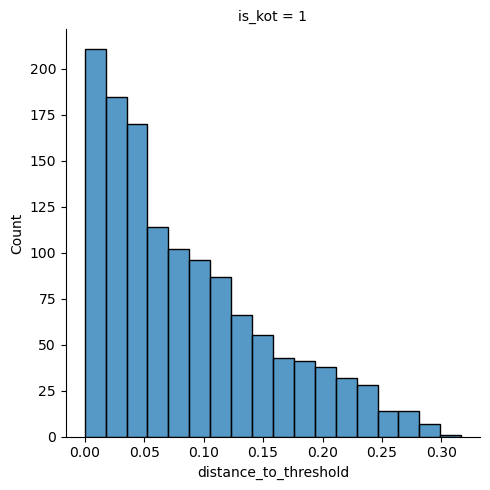

In [33]:
# wie weit der Wert von der erlaubten Grenze entfernt ist.
# distance_to_threshold =abs_weight_diff − (exp_weight_kg × 0.012)
import seaborn as sns 
sns.displot(data = df_kickout, x = "distance_to_threshold", col = "is_kot")

In [34]:
df_kickout["distance_to_threshold"].describe()

count    1.304000e+03
mean     8.503042e-02
std      7.007975e-02
min     -1.353084e-16
25%      2.698900e-02
50%      6.599500e-02
75%      1.265005e-01
max      3.165520e-01
Name: distance_to_threshold, dtype: float64

In [35]:
bins = [0, 0.005, 0.01, 0.02, 0.05, float("inf")]
df_kickout = df_kickout.copy()
df_kickout["distance_bin"] = pd.cut(
    df_kickout["distance_to_threshold"],
    bins=bins
)

In [36]:
# Bins definieren
bins = [0, 0.005, 0.01, 0.015, 0.02, 0.05, 0.1]

df["ratio_bin"] = pd.cut(df["weight_diff_ratio"], bins=bins)

# Kickout-Rate pro Bin
df.groupby("ratio_bin", observed=True)["is_kot"].agg(["count","mean"])

,count,mean
ratio_bin,,
"(0.0, 0.005]",1234,0.00000
"(0.005, 0.01]",2520,0.00000
"(0.01, 0.015]",796,0.11809
"(0.015, 0.02]",118,1.00000
"(0.02, 0.05]",737,1.00000
"(0.05, 0.1]",355,1.00000


In [37]:
df_kickout.columns

Index(['shipment_id', 'timestamp', 'severity', 'thread', 'source', 'event',
       'station', 'box_barcode', 'articles', 'exp_weight_kg', 'act_weight_kg',
       'tare_weight_kg', 'product_weight_kg', 'abs_weight_diff',
       'print_quality_pct', 'line_speed_mps', 'slam', 'iso_grade',
       'pckg_problem_found', 'weight_diff', 'weight_diff_ratio',
       'distance_to_threshold', 'is_kot', 'hour', 'distance_bin'],
      dtype='object')

In [38]:
counts = df_kickout["distance_bin"].value_counts()

In [39]:
counts/1172 * 100

distance_bin
(0.05, inf]      64.846416
(0.02, 0.05]     26.023891
(0.01, 0.02]      9.812287
(0.0, 0.005]      5.546075
(0.005, 0.01]     4.778157
Name: count, dtype: float64

In [40]:
#Kickout-Rate pro Drucker:
df.groupby("thread_label")["is_kot"].mean()

KeyError: 'thread_label'